# Exit Strategies for Risk Management
**Docker image**: `ml4t`

## Purpose
Compare exit strategies that protect profits and limit losses on real ETF data:
fixed stops, trailing stops, ATR-scaled volatility exits, an ML exit signal, and
hybrid combinations. We measure stop-out frequency, win rate, and the trade-off
between loss control and avoidable churn.

## Learning Objectives
After completing this notebook, you will be able to:
- Implement fixed and trailing stop-loss rules
- Design ATR-scaled volatility-adjusted exits
- Calibrate stops to a strategy's realized MAE/MFE excursion profile
- Compare rule-based, ML-driven, and hybrid exit policies on the same trades

## Book reference
- Section 19.4 — Drawdowns, Path Risk, and Time-to-Recovery
- Section 19.7 — Adaptive Risk Controls Without Leakage

## Prerequisites
- Familiarity with OHLCV bars, ATR, and simple classification metrics
- Comfort interpreting stop-loss tradeoffs in terms of win rate and whipsaw risk

**Companion**: For the ML two-model entry/exit architecture, see
[`08_ml_exit_signals`](08_ml_exit_signals.ipynb).

## Setup

In [1]:
"""Exit Strategies for Risk Management — compare fixed, trailing, and volatility-adjusted stop-loss rules."""

import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest.analytics import MAEMFEAnalyzer
from ml4t.backtest.risk import (
    ActionType,
    AllOf,
    AnyOf,
    PositionState,
    RuleChain,
    SignalExit,
    StopLoss,
    TakeProfit,
    TighteningTrailingStop,
    TimeExit,
    TrailingStop,
    VolatilityStop,
    VolatilityTrailingStop,
)
from ml4t.backtest.types import Trade
from ml4t.diagnostic.config import (
    BarrierAnalysisSettings,
    BarrierColumnSettings,
    BarrierConfig,
)
from ml4t.diagnostic.evaluation import BarrierAnalysis
from plotly.subplots import make_subplots
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
SEED = 42

In [3]:
np.random.seed(SEED)

## 1. Data Preparation

In [4]:
# Load sample data from canonical ETF source
SYMBOL = "SPY"
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"

print(f"Loading {SYMBOL} data from canonical source...")
etf_data = load_etfs()

# Filter for SPY and date range
df = etf_data.filter(
    (pl.col("symbol") == SYMBOL)
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
).sort("timestamp")

print(f"Loaded {len(df):,} daily bars")

Loading SPY data from canonical source...
Loaded 1,509 daily bars


In [5]:
# Try to load upstream ML predictions (Ch12/Ch13) for integration
OUTPUT_DIR = get_output_dir(19, "exit_strategies")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
set_global_seeds(SEED)

UPSTREAM_PREDS_AVAILABLE = False
upstream_preds = None

# Check for ETF predictions from Ch12 (GBM) or Ch13 (DL)
CASE_DIR = get_case_study_dir("etfs")
for stage_dir, pred_file in [
    ("models/gbm", "gbm_predictions.parquet"),
    ("models/deep_learning", "dl_predictions.parquet"),
]:
    pred_path = CASE_DIR / stage_dir / pred_file
    if pred_path.exists():
        upstream_preds = pl.read_parquet(pred_path)
        # Filter to our symbol if multi-asset
        if "symbol" in upstream_preds.columns:
            upstream_preds = upstream_preds.filter(pl.col("symbol") == SYMBOL)
        print(f"[OK] Loaded predictions from {stage_dir}: {len(upstream_preds):,} rows")
        UPSTREAM_PREDS_AVAILABLE = True
        break

if not UPSTREAM_PREDS_AVAILABLE:
    print("[WARN] No upstream ML predictions found - using standalone exit model")
    print("  Run Ch12/Ch13 ETF notebooks to generate predictions for integration")

[WARN] No upstream ML predictions found - using standalone exit model
  Run Ch12/Ch13 ETF notebooks to generate predictions for integration


In [7]:
# Add the base price and volatility features used by the exit rules.
df = df.with_columns(
    [
        (pl.col("close").pct_change()).alias("returns"),
        (pl.col("close").pct_change(5)).alias("returns_5d"),
        pl.max_horizontal(
            pl.col("high") - pl.col("low"),
            (pl.col("high") - pl.col("close").shift(1)).abs(),
            (pl.col("low") - pl.col("close").shift(1)).abs(),
        )
        .rolling_mean(14)
        .alias("atr_14"),
        pl.col("close").pct_change().rolling_std(20).alias("volatility_20"),
        pl.col("close").rolling_mean(20).alias("sma_20"),
        pl.col("close").rolling_mean(50).alias("sma_50"),
        pl.col("close").pct_change().alias("change"),
    ]
)

In [8]:
# Complete the RSI-style smoothing used in the ML exit model.
df = df.with_columns(
    [
        pl.when(pl.col("change") > 0).then(pl.col("change")).otherwise(0).alias("gain"),
        pl.when(pl.col("change") < 0).then(-pl.col("change")).otherwise(0).alias("loss"),
    ]
)

df = df.with_columns(
    [
        pl.col("gain").rolling_mean(14).alias("avg_gain"),
        pl.col("loss").rolling_mean(14).alias("avg_loss"),
    ]
)

df = df.with_columns(
    [
        (100 - 100 / (1 + pl.col("avg_gain") / pl.col("avg_loss"))).alias("rsi_14"),
    ]
)

df = df.drop_nulls()
print(f"After indicators: {len(df):,} bars")

After indicators: 1,460 bars


A single helper keeps the manual simulations consistent about how they record
trade-level exit information.

In [9]:
def build_exit_result(
    entry_idx: int,
    exit_idx: int,
    entry_price: float,
    exit_price: float,
    exit_type: str,
    extra: dict | None = None,
) -> dict:
    """Create a standard exit record for the simulation sections."""
    result = {
        "entry_idx": entry_idx,
        "exit_idx": exit_idx,
        "entry_price": entry_price,
        "exit_price": exit_price,
        "return": (exit_price / entry_price) - 1,
        "exit_type": exit_type,
        "holding_days": exit_idx - entry_idx,
    }
    if extra:
        result.update(extra)
    return result

## 2. Fixed Take Profit / Stop Loss

The simplest exit strategy: exit when price hits a fixed percentage target or stop.

The fixed-stop configuration exposes the two policy parameters: the acceptable loss and the take-profit target.

In [10]:
@dataclass
class FixedExitConfig:
    """Configuration for fixed take profit / stop loss."""

    take_profit_pct: float = 0.05  # 5% take profit
    stop_loss_pct: float = 0.02  # 2% stop loss

The simulator scans forward from each entry until either barrier is hit or the holding limit expires.

In [11]:
def simulate_fixed_exits(
    prices: np.ndarray,
    entry_indices: np.ndarray,
    config: FixedExitConfig,
    max_holding_days: int = 20,
) -> list[dict]:
    """Simulate fixed take-profit and stop-loss exits."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        tp_price = entry_price * (1 + config.take_profit_pct)
        sl_price = entry_price * (1 - config.stop_loss_pct)
        exit_idx = window_end
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            if prices[i] >= tp_price:
                exit_idx = i
                exit_type = "take_profit"
                break
            if prices[i] <= sl_price:
                exit_idx = i
                exit_type = "stop_loss"
                break

        exit_price = (
            tp_price
            if exit_type == "take_profit"
            else sl_price
            if exit_type == "stop_loss"
            else prices[exit_idx]
        )
        results.append(build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type))

    return results

In [12]:
# Generate random entry signals (for demonstration)
# In practice, these would come from your alpha signal
n_trades = 100
entry_indices = np.sort(np.random.choice(range(50, len(df) - 50), size=n_trades, replace=False))

# Simulate with different stop loss levels
prices = df["close"].to_numpy()
# Timestamp per bar (df coordinate). The ML section keys exit probabilities
# by timestamp because df_ml drops additional warm-up / forward-target rows
# and therefore does NOT share df's integer index.
# Normalize to a single unit so timestamp keys hash-match across the
# polars-native and pandas-converted datetime64 arrays (different units
# are ==-equal but not hash-equal).
bar_timestamps = df["timestamp"].to_numpy().astype("datetime64[ns]")

configs = [
    FixedExitConfig(take_profit_pct=0.05, stop_loss_pct=0.01),  # Tight stop
    FixedExitConfig(take_profit_pct=0.05, stop_loss_pct=0.02),  # Medium stop
    FixedExitConfig(take_profit_pct=0.05, stop_loss_pct=0.03),  # Wide stop
]

results_by_config = {}
for config in configs:
    results = simulate_fixed_exits(prices, entry_indices, config)
    results_by_config[f"SL={config.stop_loss_pct:.0%}"] = results

Tighter fixed stops cut more trades short, so the stop-loss count rises and the
timeout count falls as `SL` shrinks. Mean return is non-monotone in stop width
because tight stops avoid deep drawdowns but also exit profitable trades early.

In [13]:
fixed_summary_rows = []
for name, results in results_by_config.items():
    returns = [r["return"] for r in results]
    exit_types = [r["exit_type"] for r in results]
    fixed_summary_rows.append(
        {
            "config": name,
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "take_profits": exit_types.count("take_profit"),
            "stop_losses": exit_types.count("stop_loss"),
            "timeouts": exit_types.count("timeout"),
        }
    )
fixed_summary_df = pd.DataFrame(fixed_summary_rows)
fixed_summary_df.round(2)

,config,mean_return_pct,win_rate_pct,take_profits,stop_losses,timeouts
0,SL=1%,0.69,35.0,15,64,21
1,SL=2%,0.70,49.0,16,48,36
2,SL=3%,0.46,53.0,16,40,44


In [14]:
# Persist trade-return distribution by stop-loss config for the figure-19.4 publication script.
fixed_returns_rows = []
for name, results in results_by_config.items():
    for r in results:
        fixed_returns_rows.append({"config": name, "return_pct": r["return"] * 100})
pl.DataFrame(fixed_returns_rows).write_parquet(OUTPUT_DIR / "fixed_stop_loss_returns.parquet")

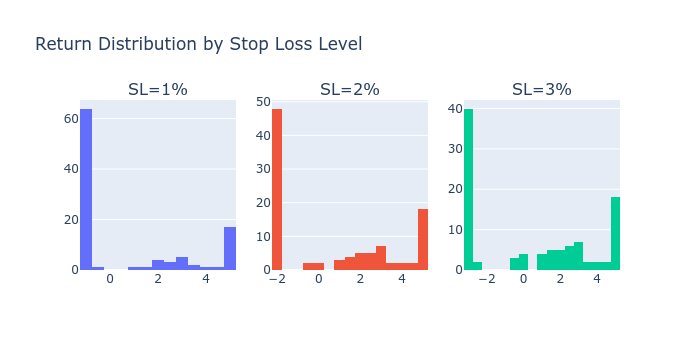

In [15]:
# Visualize exit distribution
fig = make_subplots(rows=1, cols=3, subplot_titles=list(results_by_config.keys()))

for i, (name, results) in enumerate(results_by_config.items(), 1):
    returns = [r["return"] * 100 for r in results]
    fig.add_trace(go.Histogram(x=returns, nbinsx=30, name=name), row=1, col=i)

fig.update_layout(title="Return Distribution by Stop Loss Level", height=350, showlegend=False)
fig.show()

## 3. Trailing Stop Loss

Trailing stops follow price upward, locking in profits as the position moves favorably.

Trailing-stop settings separate the initial protection level from the distance that trails the high-water mark.

In [16]:
@dataclass
class TrailingStopConfig:
    """Configuration for trailing stop loss."""

    initial_stop_pct: float = 0.02  # Initial stop distance
    trail_pct: float = 0.015  # Trailing distance

The trailing-stop simulator updates the stop as new highs arrive and exits once price crosses that moving floor.

In [17]:
def simulate_trailing_stops(
    prices: np.ndarray,
    highs: np.ndarray,
    entry_indices: np.ndarray,
    config: TrailingStopConfig,
    max_holding_days: int = 50,
) -> list:
    """Simulate a trailing stop that ratchets upward with the high-water mark."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        highest_since_entry = entry_price
        stop_price = entry_price * (1 - config.initial_stop_pct)
        exit_idx = window_end
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            if highs[i] > highest_since_entry:
                highest_since_entry = highs[i]
                stop_price = max(stop_price, highest_since_entry * (1 - config.trail_pct))

            if prices[i] <= stop_price:
                exit_idx = i
                exit_type = "trailing_stop"
                break

        results.append(
            build_exit_result(
                entry_idx,
                exit_idx,
                entry_price,
                prices[exit_idx],
                exit_type,
                {"highest_seen": highest_since_entry, "final_stop": stop_price},
            )
        )

    return results

In [18]:
# Simulate trailing stops
highs = df["high"].to_numpy()

trailing_configs = [
    TrailingStopConfig(initial_stop_pct=0.02, trail_pct=0.01),  # Tight trail
    TrailingStopConfig(initial_stop_pct=0.02, trail_pct=0.02),  # Medium trail
    TrailingStopConfig(initial_stop_pct=0.02, trail_pct=0.03),  # Wide trail
]

trailing_results = {}
for config in trailing_configs:
    results = simulate_trailing_stops(prices, highs, entry_indices, config)
    trailing_results[f"Trail={config.trail_pct:.0%}"] = results

# Compare to fixed stop
fixed_results = simulate_fixed_exits(
    prices, entry_indices, FixedExitConfig(take_profit_pct=0.10, stop_loss_pct=0.02)
)

Trailing stops let winners run by ratcheting the stop upward. Tight trails take
fewer dollars off the table but exit on minor pullbacks; wider trails hold positions
longer and on this sample finish closer to the fixed-stop baseline.

In [19]:
trailing_rows = []
for name, results in trailing_results.items():
    returns = [r["return"] for r in results]
    trailing_rows.append(
        {
            "config": name,
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "avg_hold_days": float(np.mean([r["holding_days"] for r in results])),
        }
    )
trailing_rows.append(
    {
        "config": "Fixed SL/TP (baseline)",
        "mean_return_pct": np.mean([r["return"] for r in fixed_results]) * 100,
        "win_rate_pct": sum(1 for r in fixed_results if r["return"] > 0) / len(fixed_results) * 100,
        "avg_hold_days": float(np.mean([r["holding_days"] for r in fixed_results])),
    }
)
trailing_summary_df = pd.DataFrame(trailing_rows)
trailing_summary_df.round(2)

,config,mean_return_pct,win_rate_pct,avg_hold_days
0,Trail=1%,-0.08,45.0,6.64
1,Trail=2%,0.07,39.0,14.92
2,Trail=3%,0.69,41.0,21.84
3,Fixed SL/TP (baseline),0.65,48.0,13.42


## 4. Volatility-Adjusted Stops (ATR-Based)

ATR-based stops adapt to market volatility, using wider stops in volatile markets
and tighter stops in calm markets.

ATR configuration determines how many volatility units to allow on the downside and upside.

In [20]:
@dataclass
class ATRStopConfig:
    """Configuration for ATR-based stops."""

    atr_multiplier: float = 2.0  # Stop = entry - N * ATR
    take_profit_multiplier: float = 3.0  # TP = entry + N * ATR

ATR exits reuse the same barrier logic as fixed stops, but rescale both barriers by current volatility.

In [21]:
def simulate_atr_exits(
    prices: np.ndarray,
    atr: np.ndarray,
    entry_indices: np.ndarray,
    config: ATRStopConfig,
    max_holding_days: int = 30,
) -> list:
    """Simulate ATR-based exits with volatility-scaled barriers."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        current_atr = atr[entry_idx]
        stop_price = entry_price - config.atr_multiplier * current_atr
        tp_price = entry_price + config.take_profit_multiplier * current_atr
        exit_idx = window_end
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            if prices[i] >= tp_price:
                exit_idx = i
                exit_type = "take_profit"
                break
            if prices[i] <= stop_price:
                exit_idx = i
                exit_type = "stop_loss"
                break

        exit_price = (
            tp_price
            if exit_type == "take_profit"
            else stop_price
            if exit_type == "stop_loss"
            else prices[exit_idx]
        )
        extra = {
            "atr_at_entry": current_atr,
            "stop_distance_pct": (entry_price - stop_price) / entry_price,
        }
        results.append(
            build_exit_result(entry_idx, exit_idx, entry_price, exit_price, exit_type, extra)
        )

    return results

In [22]:
# Simulate ATR-based exits
atr = df["atr_14"].to_numpy()

atr_configs = [
    ATRStopConfig(atr_multiplier=1.5, take_profit_multiplier=2.0),  # Tight
    ATRStopConfig(atr_multiplier=2.0, take_profit_multiplier=3.0),  # Medium
    ATRStopConfig(atr_multiplier=3.0, take_profit_multiplier=4.0),  # Wide
]

atr_results = {}
for config in atr_configs:
    results = simulate_atr_exits(prices, atr, entry_indices, config)
    atr_results[f"ATR×{config.atr_multiplier}"] = results

ATR-scaled stops widen automatically when realized volatility is high and tighten
when it's calm; the standard deviation of stop distance shows how much the rule
adapts within a single configuration.

In [23]:
atr_rows = []
for name, results in atr_results.items():
    returns = [r["return"] for r in results]
    stop_distances = [r["stop_distance_pct"] * 100 for r in results]
    atr_rows.append(
        {
            "config": name,
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "avg_stop_distance_pct": float(np.mean(stop_distances)),
            "stop_distance_std_pct": float(np.std(stop_distances)),
        }
    )
atr_summary_df = pd.DataFrame(atr_rows)
atr_summary_df.round(2)

,config,mean_return_pct,win_rate_pct,avg_stop_distance_pct,stop_distance_std_pct
0,ATR×1.5,0.53,53.0,1.94,0.82
1,ATR×2.0,0.82,53.0,2.58,1.10
2,ATR×3.0,0.78,53.0,3.88,1.65


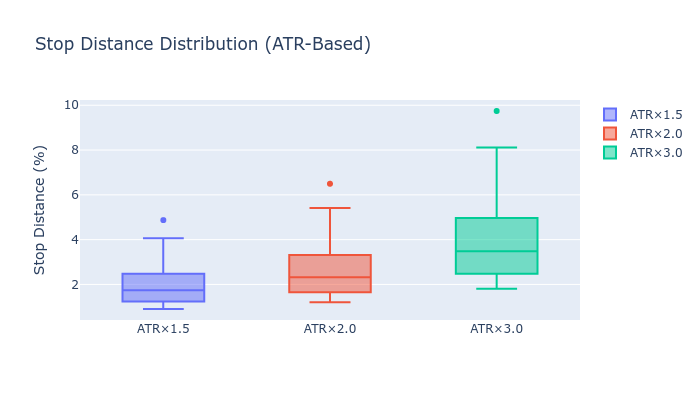

In [24]:
# Visualize how stop distance varies with volatility
fig = go.Figure()

for name, results in atr_results.items():
    stop_distances = [r["stop_distance_pct"] * 100 for r in results]
    fig.add_trace(go.Box(y=stop_distances, name=name))

fig.update_layout(
    title="Stop Distance Distribution (ATR-Based)",
    yaxis_title="Stop Distance (%)",
    height=400,
)
fig.show()

## 5. ML-Based Exit Signals

Train a classifier to predict adverse price moves and use predictions for exits.

**Approach**:
- Target: Will price drop >2% in next 5 days?
- Features: Technical indicators, recent returns, volatility
- **Integration**: If Ch12/Ch13 entry predictions available, use as additional feature
- Model: Gradient Boosting
- Exit: When model predicts high probability of adverse move

In [25]:
# Prepare ML features and target
df_ml = df.with_columns(
    [
        # Target: price drops >2% in next 5 days
        (pl.col("close").shift(-5) / pl.col("close") - 1 < -0.02).cast(pl.Int32).alias("target"),
        # Features
        pl.col("returns").alias("ret_1d"),
        pl.col("returns_5d").alias("ret_5d"),
        (pl.col("close").pct_change(10)).alias("ret_10d"),
        (pl.col("close").pct_change(20)).alias("ret_20d"),
        pl.col("volatility_20").alias("vol_20d"),
        pl.col("rsi_14").alias("rsi"),
        ((pl.col("close") - pl.col("sma_20")) / pl.col("sma_20")).alias("dist_sma20"),
        ((pl.col("close") - pl.col("sma_50")) / pl.col("sma_50")).alias("dist_sma50"),
        (pl.col("volume") / pl.col("volume").rolling_mean(20)).alias("vol_ratio"),
    ]
).drop_nulls()

In [26]:
# Integrate upstream ML predictions as additional feature (if available)
if UPSTREAM_PREDS_AVAILABLE and upstream_preds is not None:
    # Join upstream predictions to our dataset
    upstream_for_join = upstream_preds.select(
        [
            pl.col("timestamp").cast(pl.Date),
            pl.col("y_pred_proba").alias("entry_signal"),  # Entry model's confidence
        ]
    )
    df_ml = df_ml.join(upstream_for_join, on="timestamp", how="left")
    # Fill missing with neutral value
    df_ml = df_ml.with_columns(pl.col("entry_signal").fill_null(0.5))
    print(
        f"[OK] Added upstream entry signal as feature (coverage: {(df_ml['entry_signal'] != 0.5).mean() * 100:.1f}%)"
    )
else:
    # Add placeholder for consistent feature list
    df_ml = df_ml.with_columns(pl.lit(0.5).alias("entry_signal"))

# Features list - entry_signal from Ch12/13 adds value: low entry confidence → consider exit
FEATURES = [
    "ret_1d",
    "ret_5d",
    "ret_10d",
    "ret_20d",
    "vol_20d",
    "rsi",
    "dist_sma20",
    "dist_sma50",
    "vol_ratio",
    "entry_signal",  # Upstream ML prediction (0.5 if unavailable)
]

print(f"ML dataset: {len(df_ml):,} samples")
print(f"Target rate: {df_ml['target'].mean() * 100:.1f}% (adverse moves)")

ML dataset: 1,435 samples
Target rate: 15.0% (adverse moves)


In [27]:
# Train/test split (time series aware). df_ml is sorted by timestamp, so a
# row-based split is chronological. We keep the test timestamps to align
# probabilities back to price-bar indices, since df_ml has dropped warm-up
# and forward-target rows and no longer shares df's integer index.
df_pd = df_ml.to_pandas()
train_size = int(len(df_pd) * 0.7)

X_train = df_pd[FEATURES].iloc[:train_size]
y_train = df_pd["target"].iloc[:train_size]
X_test = df_pd[FEATURES].iloc[train_size:]
y_test = df_pd["target"].iloc[train_size:]
test_timestamps = df_pd["timestamp"].iloc[train_size:].to_numpy().astype("datetime64[ns]")

print(f"Train: {len(X_train):,} samples, Test: {len(X_test):,} samples")

Train: 1,004 samples, Test: 431 samples


In [28]:
# Train model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluation
print("\nModel Performance (Test Set):")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Hold", "Exit Signal"]))


Model Performance (Test Set):
AUC-ROC: 0.551

Classification Report:
              precision    recall  f1-score   support

        Hold       0.81      0.93      0.87       350
 Exit Signal       0.18      0.06      0.09        81

    accuracy                           0.77       431
   macro avg       0.49      0.50      0.48       431
weighted avg       0.69      0.77      0.72       431



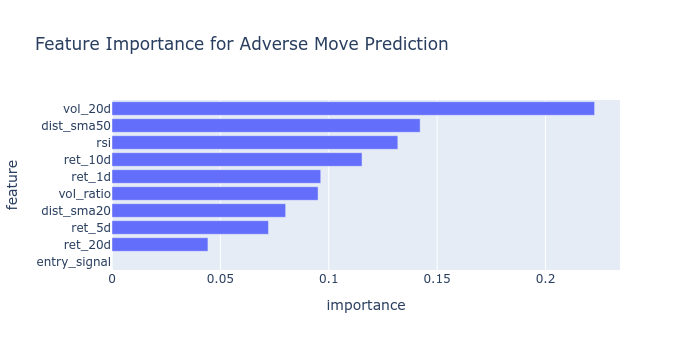

In [29]:
# Feature importance
importance_df = pd.DataFrame(
    {"feature": FEATURES, "importance": model.feature_importances_}
).sort_values("importance", ascending=True)

fig = px.bar(
    importance_df,
    x="importance",
    y="feature",
    orientation="h",
    title="Feature Importance for Adverse Move Prediction",
)
fig.update_layout(height=350)
fig.show()

The exit probabilities are keyed by timestamp, not by row position. The
helper looks up the bar's timestamp in `proba_by_ts`; bars without a
test-set probability (training period, or warm-up rows dropped from
`df_ml`) never trigger an ML exit.

In [30]:
def ml_exit_triggered(
    proba_by_ts: dict,
    idx: int,
    exit_threshold: float,
    bar_timestamps: np.ndarray,
) -> bool:
    """Return True when the bar's timestamped exit probability exceeds the threshold."""
    proba = proba_by_ts.get(bar_timestamps[idx])
    return proba is not None and proba > exit_threshold

The ML exit simulator treats a high adverse-move probability as an early exit signal.

In [31]:
def simulate_ml_exits(
    prices: np.ndarray,
    proba_by_ts: dict,
    entry_indices: np.ndarray,
    bar_timestamps: np.ndarray,
    exit_threshold: float = 0.5,
    max_holding_days: int = 30,
) -> list:
    """
    Simulate exits based on ML predictions.

    Exit when the model's timestamped adverse-move probability exceeds the
    threshold. Only entries whose bars carry a test-set probability are
    simulated; the caller restricts ``entry_indices`` to the test period.
    """
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        exit_idx = window_end
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            if ml_exit_triggered(proba_by_ts, i, exit_threshold, bar_timestamps):
                exit_idx = i
                exit_type = "ml_signal"
                break

        results.append(
            build_exit_result(entry_idx, exit_idx, entry_price, prices[exit_idx], exit_type)
        )

    return results

In [32]:
# Map each test bar's timestamp to its exit probability, then restrict the
# entry universe to bars on or after the first test timestamp. This aligns
# probabilities to price-bar indices through timestamps rather than assuming
# df and df_ml share an integer index (they do not).
proba_by_ts = dict(zip(test_timestamps, y_pred_proba, strict=True))
test_cutoff_ts = test_timestamps.min()
test_entries = entry_indices[bar_timestamps[entry_indices] >= test_cutoff_ts]

ml_results = {}
for threshold in [0.3, 0.5, 0.7]:
    results = simulate_ml_exits(
        prices, proba_by_ts, test_entries, bar_timestamps, exit_threshold=threshold
    )
    if results:
        ml_results[f"ML (p>{threshold})"] = results

# Baseline: no ML exit (just timeout)
baseline_results = simulate_ml_exits(
    prices,
    {},  # Empty map → no bar ever triggers an ML exit
    test_entries,
    bar_timestamps,
    exit_threshold=2.0,  # Never triggers
)

if baseline_results:
    ml_results["No Exit Signal"] = baseline_results

At each probability threshold the ML rule fires more often when the threshold is low
and falls back to time-exit when the threshold is high. The threshold is the lever
that trades off coverage against signal quality.

In [33]:
ml_rows = []
for name, results in ml_results.items():
    returns = [r["return"] for r in results]
    exit_types = [r["exit_type"] for r in results]
    ml_rows.append(
        {
            "config": name,
            "n_trades": len(results),
            "mean_return_pct": np.mean(returns) * 100,
            "win_rate_pct": sum(1 for r in returns if r > 0) / len(returns) * 100,
            "ml_exits": exit_types.count("ml_signal"),
            "timeouts": exit_types.count("timeout"),
        }
    )
ml_summary_df = pd.DataFrame(ml_rows)
ml_summary_df.round(2)

,config,n_trades,mean_return_pct,win_rate_pct,ml_exits,timeouts
0,ML (p>0.3),29,-0.31,51.72,20,9
1,ML (p>0.5),29,-0.14,51.72,17,12
2,ML (p>0.7),29,0.22,51.72,5,24
3,No Exit Signal,29,-0.45,48.28,0,29


Lowering the threshold makes the ML rule fire on more bars (more
`ml_exits`, fewer `timeouts`), but on this single-symbol sample the
mean-return and win-rate differences across thresholds and against the
no-signal baseline are small — consistent with the near-coin-flip AUC.
The ML exit earns its place as an overlay, not as a standalone policy.

## 6. Combining Exit Strategies

In practice, combine multiple exit signals:
- Stop loss for downside protection
- Take profit for upside capture
- Trailing stop to lock in gains
- ML signal for regime detection

The hybrid policy exposes which mix of fixed, trailing, and ML exits drives the final path.

In [34]:
@dataclass
class HybridExitConfig:
    """Combined exit strategy configuration."""

    # Fixed stops
    initial_stop_pct: float = 0.02
    take_profit_pct: float = 0.06

    # Trailing
    enable_trailing: bool = True
    trail_pct: float = 0.015

    # ML
    enable_ml: bool = True
    ml_threshold: float = 0.5

The simulator evaluates the barriers in priority order so we can attribute each exit to a specific trigger.

In [35]:
def simulate_hybrid_exits(
    prices: np.ndarray,
    highs: np.ndarray,
    proba_by_ts: dict | None,
    entry_indices: np.ndarray,
    config: HybridExitConfig,
    bar_timestamps: np.ndarray,
    max_holding_days: int = 30,
) -> list:
    """Simulate hybrid exit strategy combining multiple signals."""
    results = []

    for entry_idx in entry_indices:
        window_end = min(entry_idx + max_holding_days, len(prices) - 1)
        entry_price = prices[entry_idx]
        highest_since_entry = entry_price
        stop_price = entry_price * (1 - config.initial_stop_pct)
        tp_price = entry_price * (1 + config.take_profit_pct)
        exit_idx = window_end
        exit_type = "timeout"

        for i in range(entry_idx + 1, window_end + 1):
            if config.enable_trailing and highs[i] > highest_since_entry:
                highest_since_entry = highs[i]
                stop_price = max(stop_price, highest_since_entry * (1 - config.trail_pct))

            if prices[i] <= stop_price:
                exit_idx = i
                exit_type = "stop_loss"
                break
            if prices[i] >= tp_price:
                exit_idx = i
                exit_type = "take_profit"
                break
            if config.enable_ml and proba_by_ts is not None:
                if ml_exit_triggered(proba_by_ts, i, config.ml_threshold, bar_timestamps):
                    exit_idx = i
                    exit_type = "ml_signal"
                    break

        results.append(
            build_exit_result(entry_idx, exit_idx, entry_price, prices[exit_idx], exit_type)
        )

    return results

In [36]:
# Compare hybrid strategies
hybrid_configs = {
    "Fixed Only": HybridExitConfig(enable_trailing=False, enable_ml=False),
    "Fixed + Trailing": HybridExitConfig(enable_trailing=True, enable_ml=False),
    "Fixed + ML": HybridExitConfig(enable_trailing=False, enable_ml=True),
    "Full Hybrid": HybridExitConfig(enable_trailing=True, enable_ml=True),
}

hybrid_results = {}
for name, config in hybrid_configs.items():
    results = simulate_hybrid_exits(
        prices, highs, proba_by_ts, test_entries, config=config, bar_timestamps=bar_timestamps
    )
    if results:
        hybrid_results[name] = results

In [37]:
print("\nHybrid Exit Strategy Comparison")
print("=" * 60)

comparison_data = []
for name, results in hybrid_results.items():
    returns = [r["return"] for r in results]
    exit_types = [r["exit_type"] for r in results]

    comparison_data.append(
        {
            "Strategy": name,
            "Mean Return": f"{np.mean(returns) * 100:+.2f}%",
            "Sharpe": f"{np.mean(returns) / np.std(returns) * np.sqrt(252):.2f}",
            "Win Rate": f"{sum(1 for r in returns if r > 0) / len(returns) * 100:.1f}%",
            "Stop Losses": exit_types.count("stop_loss"),
            "Take Profits": exit_types.count("take_profit"),
            "ML Exits": exit_types.count("ml_signal"),
        }
    )

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_markdown(index=False))


Hybrid Exit Strategy Comparison
| Strategy         | Mean Return   |   Sharpe | Win Rate   |   Stop Losses |   Take Profits |   ML Exits |
|:-----------------|:--------------|---------:|:-----------|--------------:|---------------:|-----------:|
| Fixed Only       | -0.24%        |    -0.98 | 34.5%      |            18 |              6 |          0 |
| Fixed + Trailing | -0.32%        |    -2.16 | 34.5%      |            27 |              2 |          0 |
| Fixed + ML       | +0.40%        |     1.76 | 48.3%      |            13 |              5 |          7 |
| Full Hybrid      | -0.16%        |    -1.08 | 41.4%      |            22 |              1 |          6 |


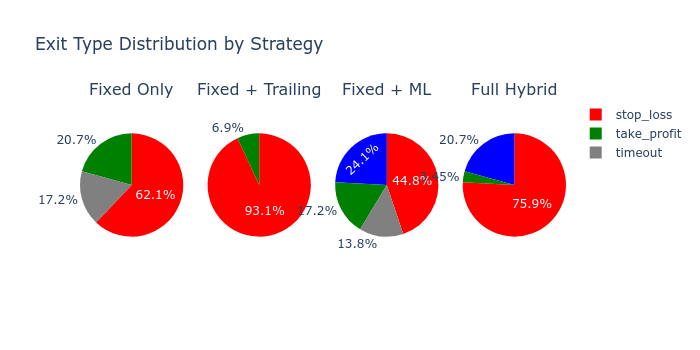

In [38]:
# Exit type breakdown
# Pie charts need 'domain' type subplots, not 'xy'
fig = make_subplots(
    rows=1,
    cols=len(hybrid_results),
    subplot_titles=list(hybrid_results.keys()),
    specs=[[{"type": "domain"} for _ in range(len(hybrid_results))]],
)

exit_type_colors = {
    "stop_loss": "red",
    "take_profit": "green",
    "ml_signal": "blue",
    "timeout": "gray",
}

for i, (name, results) in enumerate(hybrid_results.items(), 1):
    exit_types = [r["exit_type"] for r in results]
    type_counts = pd.Series(exit_types).value_counts()

    fig.add_trace(
        go.Pie(
            labels=type_counts.index,
            values=type_counts.values,
            marker_colors=[exit_type_colors.get(t, "gray") for t in type_counts.index],
            showlegend=(i == 1),
        ),
        row=1,
        col=i,
    )

fig.update_layout(title="Exit Type Distribution by Strategy", height=350)
fig.show()

## 7. ml4t-backtest Risk Rules

The manual simulations above teach how exit rules work internally. For production,
use **ml4t.backtest.risk** - a composable library of position-level exit rules.

**Key Concepts:**
- **PositionRule**: Base class for rules that act on individual positions
- **RuleChain**: Compose multiple rules (evaluated in order)
- **AllOf/AnyOf**: Logical AND/OR composition of rules

**Available Rules:**
| Rule | Description |
|------|-------------|
| `StopLoss` | Exit when position loses N% |
| `TakeProfit` | Exit when position gains N% |
| `TrailingStop` | Trail price with fixed percentage |
| `TighteningTrailingStop` | Trail tightens as profit grows |
| `VolatilityStop` | ATR-based stop loss |
| `VolatilityTrailingStop` | ATR-based trailing stop |
| `TimeExit` | Exit after N bars |
| `SignalExit` | Exit on external signal |

In [39]:
# Example 1: Basic StopLoss / TakeProfit composition
#
# RuleChain evaluates rules in order, first to trigger wins

basic_exit = RuleChain(
    rules=[
        StopLoss(pct=0.02),  # 2% stop loss
        TakeProfit(pct=0.05),  # 5% take profit
        TimeExit(max_bars=20),  # Exit after 20 bars if neither triggered
    ]
)

print("Basic Exit RuleChain:")
print(f"  Rules: {[type(r).__name__ for r in basic_exit.rules]}")

Basic Exit RuleChain:
  Rules: ['StopLoss', 'TakeProfit', 'TimeExit']


In [40]:
# Example 2: Trailing stop with take profit
#
# Trailing stop locks in profits as position moves favorably

trailing_exit = RuleChain(
    rules=[
        StopLoss(pct=0.03),  # Initial 3% stop (safety net)
        TrailingStop(pct=0.015),  # Trail 1.5% below peak
        TakeProfit(pct=0.10),  # Take 10% profit
        TimeExit(max_bars=50),  # Max 50 bar hold
    ]
)

print("\nTrailing Exit RuleChain:")
print(f"  Rules: {[type(r).__name__ for r in trailing_exit.rules]}")


Trailing Exit RuleChain:
  Rules: ['StopLoss', 'TrailingStop', 'TakeProfit', 'TimeExit']


In [41]:
# Example 3: AllOf / AnyOf composition
#
# AnyOf: Exit if ANY condition is true (OR logic)
# AllOf: Exit if ALL conditions are true (AND logic)

# AnyOf example: Exit if stop OR profit target hit
any_of_exit = AnyOf(
    rules=[
        StopLoss(pct=0.02),
        TakeProfit(pct=0.05),
    ]
)

# AllOf example: Exit only if BOTH time exceeded AND trailing triggered
# (Useful for: "after 10 bars, start trailing")
all_of_exit = AllOf(
    rules=[
        TimeExit(max_bars=10),  # Must be past 10 bars
        TrailingStop(pct=0.02),  # AND trailing triggered
    ]
)

print("\nComposition Patterns:")
print(f"  AnyOf (OR): {[type(r).__name__ for r in any_of_exit.rules]}")
print(f"  AllOf (AND): {[type(r).__name__ for r in all_of_exit.rules]}")


Composition Patterns:
  AnyOf (OR): ['StopLoss', 'TakeProfit']
  AllOf (AND): ['TimeExit', 'TrailingStop']


In [42]:
# Example 4: Volatility-adjusted exit rules
#
# VolatilityStop uses ATR for adaptive stop levels

vol_exit = RuleChain(
    rules=[
        VolatilityStop(multiplier=2.0),  # Stop = entry - 2*ATR
        TakeProfit(pct=0.08),  # 8% take profit
        TimeExit(max_bars=30),
    ]
)

print("\nVolatility-Adjusted Exit:")
print(f"  Rules: {[type(r).__name__ for r in vol_exit.rules]}")


Volatility-Adjusted Exit:
  Rules: ['VolatilityStop', 'TakeProfit', 'TimeExit']


In [43]:
# Example 5: TighteningTrailingStop - trail tightens as profit grows
#
# This rule uses a schedule: list of (return_threshold, trail_pct) tuples.
# The trail percentage decreases at higher profit levels, locking in more gains.

tightening_exit = RuleChain(
    rules=[
        StopLoss(pct=0.03),  # 3% initial stop
        TighteningTrailingStop(
            schedule=[
                (0.00, 0.03),  # At 0% profit: 3% trail
                (0.05, 0.02),  # At 5%+ profit: 2% trail
                (0.10, 0.01),  # At 10%+ profit: 1% trail
            ]
        ),
        TakeProfit(pct=0.15),  # 15% take profit
    ]
)

print("\nTightening Trailing Stop:")
print(f"  Rules: {[type(r).__name__ for r in tightening_exit.rules]}")


Tightening Trailing Stop:
  Rules: ['StopLoss', 'TighteningTrailingStop', 'TakeProfit']


### Evaluating Rules with PositionState

The examples above show rule *creation*. Now let's *evaluate* them against
concrete position states. All rules accept a `PositionState` and return a
`PositionAction` with `action`, `stop_price`, and `reason` fields.
Context data (ATR, signals) is passed via `PositionState.context`.

This helper fabricates a minimal `PositionState` so we can test one rule at a time without a full engine run.

In [44]:
def create_position_state(
    entry_price: float = 100.0,
    current_price: float = 102.0,
    quantity: int = 100,
    high_water_mark: float | None = None,
    bars_held: int = 10,
    context: dict | None = None,
) -> PositionState:
    """Create a PositionState for rule evaluation."""
    hwm = high_water_mark or max(entry_price, current_price)
    lwm = min(entry_price, current_price)
    return PositionState(
        asset="TEST",
        side="long",
        entry_price=entry_price,
        current_price=current_price,
        quantity=quantity,
        initial_quantity=quantity,
        unrealized_pnl=(current_price - entry_price) * quantity,
        unrealized_return=(current_price - entry_price) / entry_price,
        bars_held=bars_held,
        high_water_mark=hwm,
        low_water_mark=lwm,
        bar_open=current_price - 0.5,
        bar_high=current_price + 1.0,
        bar_low=current_price - 1.0,
        context=context or {},
    )

A tiny predicate keeps the rule-evaluation examples readable.

In [45]:
def should_exit(result) -> bool:
    """Check if result indicates an exit action."""
    return result.action != ActionType.HOLD

In [46]:
# Example 6: VolatilityStop and VolatilityTrailingStop evaluation
print("VolatilityStop: ATR-Based Fixed Stop")
print("=" * 60)

stop_2x = VolatilityStop(multiplier=2.0, atr_key="atr")

scenarios = [
    ("Low volatility (ATR=1.0)", 1.0, 98.0),
    ("Normal volatility (ATR=2.0)", 2.0, 98.0),
    ("High volatility (ATR=4.0)", 4.0, 98.0),
]

print("\nEntry: $100.00, Stop multiplier: 2x ATR")
print(f"{'Scenario':<30} {'ATR':>8} {'Stop Level':>12} {'Current':>10} {'Exit?':>8}")
print("-" * 70)

for name, atr_val, current_price in scenarios:
    state = create_position_state(
        entry_price=100.0, current_price=current_price, context={"atr": atr_val}
    )
    result = stop_2x.evaluate(state)
    stop_level = 100.0 - (atr_val * 2.0)
    exit_flag = "YES" if should_exit(result) else "No"
    print(f"{name:<30} {atr_val:>8.1f} ${stop_level:>10.2f} ${current_price:>9.2f} {exit_flag:>8}")

VolatilityStop: ATR-Based Fixed Stop

Entry: $100.00, Stop multiplier: 2x ATR
Scenario                            ATR   Stop Level    Current    Exit?
----------------------------------------------------------------------
Low volatility (ATR=1.0)            1.0 $     98.00 $    98.00      YES
Normal volatility (ATR=2.0)         2.0 $     96.00 $    98.00      YES
High volatility (ATR=4.0)           4.0 $     92.00 $    98.00      YES


In [47]:
# VolatilityTrailingStop: trail rises with high-water mark
print("\nVolatilityTrailingStop: ATR-Based Trailing Stop")
print("=" * 60)

trail_rule = VolatilityTrailingStop(multiplier=2.0, atr_key="atr")
entry_price = 100.0
sim_prices = [100, 102, 104, 106, 105, 103, 101, 99]
atr_val = 2.0

print(f"\nEntry: ${entry_price:.2f}, Trail: 2x ATR = ${atr_val * 2:.2f}")
print(f"{'Bar':>5} {'Price':>10} {'HWM':>10} {'Trail Stop':>12} {'Exit?':>8}")
print("-" * 50)

hwm = entry_price
for i, price in enumerate(sim_prices):
    hwm = max(hwm, price)
    trail_stop = hwm - (atr_val * 2)
    state = create_position_state(
        entry_price=entry_price,
        current_price=price,
        high_water_mark=hwm,
        context={"atr": atr_val},
    )
    result = trail_rule.evaluate(state)
    exit_flag = "EXIT" if should_exit(result) else "-"
    print(f"{i:>5} ${price:>9.2f} ${hwm:>9.2f} ${trail_stop:>11.2f} {exit_flag:>8}")


VolatilityTrailingStop: ATR-Based Trailing Stop

Entry: $100.00, Trail: 2x ATR = $4.00
  Bar      Price        HWM   Trail Stop    Exit?
--------------------------------------------------
    0 $   100.00 $   100.00 $      96.00        -
    1 $   102.00 $   102.00 $      98.00        -
    2 $   104.00 $   104.00 $     100.00        -
    3 $   106.00 $   106.00 $     102.00        -
    4 $   105.00 $   106.00 $     102.00        -
    5 $   103.00 $   106.00 $     102.00        -
    6 $   101.00 $   106.00 $     102.00     EXIT
    7 $    99.00 $   106.00 $     102.00     EXIT


In [48]:
# Example 7: SignalExit — ML-driven exit via context signal
print("\nSignalExit: ML-Driven Exit")
print("=" * 60)

signal_rule = SignalExit(signal_name="exit_signal", threshold=0.3)

print("\nLONG Position: Exits when exit_signal < -threshold")
print(f"{'Signal Value':>15} {'Exit?':>10} {'Reason':>30}")
print("-" * 60)

for signal_value in [0.5, 0.0, -0.2, -0.4, -0.8]:
    state = create_position_state(context={"exit_signal": signal_value})
    result = signal_rule.evaluate(state)
    exit_flag = "EXIT" if should_exit(result) else "Hold"
    reason = result.reason if should_exit(result) else "-"
    print(f"{signal_value:>15.2f} {exit_flag:>10} {reason:>30}")


SignalExit: ML-Driven Exit

LONG Position: Exits when exit_signal < -threshold
   Signal Value      Exit?                         Reason
------------------------------------------------------------
           0.50       Hold                              -
           0.00       Hold                              -
          -0.20       Hold                              -
          -0.40       EXIT              signal_exit_-0.40
          -0.80       EXIT              signal_exit_-0.80


### MAE/MFE-Calibrated Exit Rules

Use historical Maximum Adverse Excursion (MAE) and Maximum Favorable
Excursion (MFE) to set data-driven stop and target levels. The
`MAEMFEAnalyzer` from ml4t-backtest computes optimal exit thresholds
from a set of `Trade` objects.

In [49]:
# Create synthetic trades for MAE/MFE analysis
n_mae_trades = 100

trades_list = []
trades_data = []

for i in range(n_mae_trades):
    entry_p = 100.0
    qty = 100
    returns_path = np.random.normal(0.001, 0.02, 20)
    price_path = entry_p * np.cumprod(1 + returns_path)

    exit_p = float(price_path[-1])
    mae = (entry_p - price_path.min()) / entry_p
    mfe = (price_path.max() - entry_p) / entry_p
    pnl = (exit_p - entry_p) * qty

    trade = Trade(
        symbol="TEST",
        entry_time=datetime(2023, 1, 1) + timedelta(days=i),
        exit_time=datetime(2023, 1, 1) + timedelta(days=i, hours=20),
        entry_price=entry_p,
        exit_price=exit_p,
        quantity=qty,
        pnl=pnl,
        pnl_percent=(exit_p - entry_p) / entry_p,
        bars_held=20,
        mfe=mfe,
        mae=-mae,
    )
    trades_list.append(trade)
    trades_data.append({"pnl_pct": (exit_p - entry_p) / entry_p, "mae": mae, "mfe": mfe})

mae_df = pl.DataFrame(trades_data)
print(f"Trades: {len(mae_df)}, Win rate: {(mae_df['pnl_pct'] > 0).mean():.1%}")

Trades: 100, Win rate: 67.0%


In [50]:
# Compute optimal exit levels
analyzer = MAEMFEAnalyzer(trades_list)
levels = analyzer.optimal_exit_levels(stop_percentile=90, target_percentile=75)
stop_val = levels["stop_loss"]
target_val = levels["take_profit"]

print(f"Edge Ratio: {analyzer.edge_ratio:.2f}")
print(f"90th percentile |MAE| (stop): {stop_val:.2%}")
print(f"75th percentile MFE (target): {target_val:.2%}")

# Assemble calibrated exit strategy
calibrated_exit = RuleChain(
    rules=[
        StopLoss(pct=abs(stop_val)),
        TakeProfit(pct=target_val),
        TimeExit(max_bars=30),
    ]
)
print(f"\nCalibrated rules: SL={abs(stop_val):.2%}, TP={target_val:.2%}, max 30 bars")

Edge Ratio: 2.03
90th percentile |MAE| (stop): -4.50%
75th percentile MFE (target): 2.74%

Calibrated rules: SL=4.50%, TP=2.74%, max 30 bars


### Integrating with ml4t-backtest Engine

Pass exit rules to the Engine via `position_rules` or use in Strategy.on_data():

```python
from ml4t.backtest import Engine, Strategy
from ml4t.backtest.risk import RuleChain, StopLoss, TakeProfit, TimeExit

class MyStrategy(Strategy):
    def __init__(self):
        self.exit_rules = RuleChain([
            StopLoss(pct=0.02),
            TakeProfit(pct=0.05),
            TimeExit(max_bars=20),
        ])

    def on_data(self, timestamp, data, context, broker):
        # Check existing positions for exit signals
        for position in broker.positions.values():
            state = PositionState(
                entry_price=position.avg_price,
                current_price=data[position.asset].close,
                entry_time=position.entry_time,
                current_time=timestamp,
                high_since_entry=position.high_water_mark,
                bars_held=position.bars_held,
            )
            action = self.exit_rules.evaluate(state)
            if action.should_exit:
                broker.close_position(position.asset)

        # Entry logic here...
```

### Rule Selection Guide

| Scenario | Recommended Rules |
|----------|-------------------|
| **Trend following** | TrailingStop + TimeExit |
| **Mean reversion** | StopLoss + TakeProfit (symmetric) |
| **High volatility** | VolatilityStop + TighteningTrailingStop |
| **Time-sensitive** | StopLoss + TimeExit (short max_bars) |
| **Conservative** | AllOf(TimeExit, TrailingStop) - only trail after N bars |
| **Aggressive profits** | TighteningTrailingStop (locks in gains) |

### When to Use Each Approach

| Approach | Use Case |
|----------|----------|
| **Manual simulation (Sections 2-6)** | Understanding mechanics, custom logic |
| **ml4t.backtest.risk (Section 7)** | Production backtesting, composable rules |

The manual simulations above are valuable for:
- Understanding how exit rules work internally
- Implementing custom logic not covered by built-in rules
- Rapid prototyping with numpy arrays

For production backtesting, prefer ml4t.backtest.risk because:
- The library implementations are exercised by the case-study pipelines
- Composable rule chains
- Integration with ml4t-backtest Engine
- Consistent behavior across strategies

## 7.1 Signal Quality with BarrierAnalysis

The ml4t-diagnostic library provides `BarrierAnalysis` to evaluate signal quality
using triple barrier outcomes (TP hit, SL hit, timeout) instead of simple returns.

**Why Barrier Analysis?**
- Raw returns don't distinguish *how* profits/losses occurred
- Barrier outcomes reveal if your signal predicts TP hits vs SL hits
- Helps identify if strong signals actually lead to better barrier outcomes

In [51]:
# Convert the ATR exit simulation into barrier labels.
barrier_data = []
for i, (entry_idx, result) in enumerate(zip(entry_indices, atr_results["ATR×2.0"], strict=False)):
    label_map = {"take_profit": 1, "stop_loss": -1, "timeout": 0}
    barrier_data.append(
        {
            "timestamp": df["timestamp"][int(entry_idx)],
            "symbol": SYMBOL,
            "label": label_map[result["exit_type"]],
            "label_return": result["return"],
            "label_bars": result["holding_days"],
        }
    )

barrier_labels_df = pl.DataFrame(barrier_data)

In [52]:
# Use simple momentum as a stand-in signal so we can illustrate the barrier-analysis workflow.
signal_data = []
for entry_idx in entry_indices:
    if entry_idx >= 5:
        momentum = (prices[entry_idx] / prices[entry_idx - 5]) - 1
    else:
        momentum = 0.0
    signal_data.append(
        {
            "timestamp": df["timestamp"][int(entry_idx)],
            "symbol": SYMBOL,
            "signal": momentum,
        }
    )

signal_df = pl.DataFrame(signal_data)

In [53]:
print(f"Barrier labels: {len(barrier_labels_df)} trades")
print(f"Signal data: {len(signal_df)} observations")

Barrier labels: 100 trades
Signal data: 100 observations


In [54]:
# Run BarrierAnalysis
config = BarrierConfig(
    analysis=BarrierAnalysisSettings(n_quantiles=5),
    columns=BarrierColumnSettings(
        date_col="timestamp",
        asset_col="symbol",
        signal_col="signal",
        label_col="label",
        label_return_col="label_return",
    ),
)

analysis = BarrierAnalysis(
    signal_data=signal_df,
    barrier_labels=barrier_labels_df,
    config=config,
)

# Compute hit rates by signal quintile
hit_rates = analysis.compute_hit_rates()
print("\nHit Rate Analysis by Signal Quintile")
print("=" * 60)
print(hit_rates.summary())

# Compute profit factor by quintile
profit_factor = analysis.compute_profit_factor()
print("\nProfit Factor by Signal Quintile")
print("=" * 60)
print(profit_factor.summary())


Hit Rate Analysis by Signal Quintile
Barrier Hit Rate Analysis

Observations:            100
Quantiles:                 5

Overall Hit Rates:
  Take-Profit:         43.0%
  Stop-Loss:           47.0%
  Timeout:             10.0%

Chi-Square Test (Signal Decile vs Outcome):
  Chi2 Statistic:      10.11
  P-value:            0.2576
  DoF:                     8
  Significant:            No (alpha=0.05)

Monotonicity (TP Rate vs Signal Strength):
  Monotonic:              No
  Direction:            none
  Spearman rho:       0.2052

------------------------------------------------------------
Hit Rates by Quantile:
------------------------------------------------------------
Quantile      TP Rate    SL Rate    Timeout    Count
D1              35.0%      60.0%       5.0%       20
D2              40.0%      50.0%      10.0%       20
D3              45.0%      55.0%       0.0%       20
D4              60.0%      25.0%      15.0%       20
D5              35.0%      45.0%      20.0%       20



In [55]:
# Manual visualization of barrier outcomes (works with any sample size)
barrier_df = barrier_labels_df.to_pandas()
signal_pd = signal_df.to_pandas()
merged = barrier_df.merge(signal_pd, on=["timestamp", "symbol"])

# Create quintiles
merged["signal_quintile"] = pd.qcut(
    merged["signal"], q=5, labels=["Q1 (Weak)", "Q2", "Q3", "Q4", "Q5 (Strong)"]
)

# Hit rate by quintile - compute stats directly
print("\nBarrier Outcome by Signal Quintile")
print("=" * 60)
for quintile in merged["signal_quintile"].unique():
    subset = merged[merged["signal_quintile"] == quintile]
    n = len(subset)
    if n > 0:
        tp_rate = (subset["label"] == 1).mean() * 100
        sl_rate = (subset["label"] == -1).mean() * 100
        timeout_rate = (subset["label"] == 0).mean() * 100
        print(f"\n{quintile} (n={n}):")
        print(f"  TP Hit:   {tp_rate:.1f}%")
        print(f"  SL Hit:   {sl_rate:.1f}%")
        print(f"  Timeout:  {timeout_rate:.1f}%")


Barrier Outcome by Signal Quintile

Q5 (Strong) (n=20):
  TP Hit:   35.0%
  SL Hit:   45.0%
  Timeout:  20.0%

Q4 (n=20):
  TP Hit:   60.0%
  SL Hit:   25.0%
  Timeout:  15.0%

Q3 (n=20):
  TP Hit:   45.0%
  SL Hit:   55.0%
  Timeout:  0.0%

Q2 (n=20):
  TP Hit:   40.0%
  SL Hit:   50.0%
  Timeout:  10.0%

Q1 (Weak) (n=20):
  TP Hit:   35.0%
  SL Hit:   60.0%
  Timeout:  5.0%


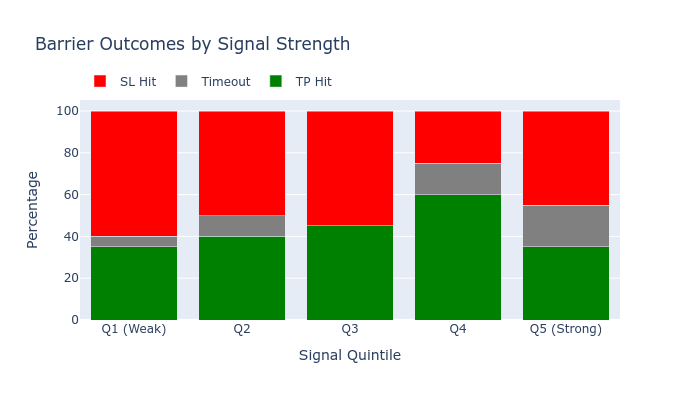

In [56]:
# Visualize barrier outcomes
outcome_summary = merged.groupby(["signal_quintile", "label"]).size().unstack(fill_value=0)
outcome_summary.columns = ["SL Hit", "Timeout", "TP Hit"]
outcome_pct = outcome_summary.div(outcome_summary.sum(axis=1), axis=0) * 100

fig = go.Figure()

for col, color in zip(["TP Hit", "Timeout", "SL Hit"], ["green", "gray", "red"], strict=False):
    fig.add_trace(
        go.Bar(
            x=outcome_pct.index.astype(str),
            y=outcome_pct[col],
            name=col,
            marker_color=color,
        )
    )

fig.update_layout(
    title="Barrier Outcomes by Signal Strength",
    xaxis_title="Signal Quintile",
    yaxis_title="Percentage",
    barmode="stack",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

**Interpreting BarrierAnalysis Results**:

| Pattern | Interpretation | Action |
|---------|----------------|--------|
| Q5 has higher TP rate | Strong signals work | Scale up on strong signals |
| Q1 has higher SL rate | Weak signals fail | Avoid/reduce weak signals |
| No quintile difference | Signal doesn't predict outcomes | Improve signal or features |
| High timeout rate | Exits too tight or signal too slow | Adjust barrier parameters |


## 8. Key Takeaways

| Strategy | Strength | Weakness |
|----------|----------|----------|
| **Fixed SL/TP** | Simple, predictable | Ignores volatility |
| **Trailing Stop** | Locks in profits | May exit too early in trends |
| **ATR-Based** | Adapts to volatility | Requires calibration |
| **ML-Based** | Can flag regime changes | Needs training data; AUC marginal |
| **Hybrid** | Combines signals | Inherits the most aggressive rule |

1. **Tighter stops reduce per-trade loss but increase whipsaws;** wider
   stops admit noise but cap fewer losers. Match the stop to the trading
   timeframe and the asset's volatility rather than a generic preference.
2. **ATR-based stops adapt to volatility without re-tuning** a fixed
   percentage; this is the cheapest robustness upgrade over fixed stops.
3. **The ML exit signal is marginal on this single-symbol sample.** AUC
   sits near coin-flip and the learned exit's lift over a pure time-exit
   is small; ML exits are best deployed as an overlay on hard stops, not
   as the primary exit. Crucially, exit probabilities must be aligned to
   price bars by *timestamp* — `df_ml` drops warm-up and forward-target
   rows, so a positional index would silently evaluate exits on the wrong
   dates.

**Next**: [`03_position_sizing_mae_mfe`](03_position_sizing_mae_mfe.ipynb)
connects these exit policies to position sizing and excursion-based
calibration; `BarrierAnalysis` validates that a signal predicts barrier
outcomes, not just returns.